In [1]:
# --- Jalankan di Colab Cell 1 ---
!pip install ultralytics roboflow

In [2]:
# --- Jalankan di Colab Cell 2 ---
import torch
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU only!'}")
# PENTING: Jika output 'CPU only!', ganti runtime ke GPU dulu!

CUDA available: True
GPU: Tesla T4


In [3]:
# --- Jalankan di Colab Cell 3 ---
# GANTI dengan API key dan project Anda dari Roboflow!
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="ke7xvBxFI02MP7n6R9hS")
project = rf.workspace("rzaldi").project("ktm-d49z9")
version = project.version(7)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...


In [4]:
# --- Jalankan di Colab Cell 3B ---
# Upload augment_dataset.py dari ScanKtm/ ke Colab:
from google.colab import files
uploaded = files.upload()  # ← pilih file augment_dataset.py

# Jalankan augmentasi dengan proporsi seimbang:
!python augment_dataset.py --dataset "{dataset.location}" --multiply-train 2 --multiply-val 5 --multiply-test 5


Saving augment_dataset.py to augment_dataset (1).py
🔧 Smart-Lab Dataset Augmentor
   Dataset: /content/ktm-7
   Multipliers: train=2x, val=5x, test=5x

   Detected splits: ['train', 'valid', 'test']

📊 BEFORE augmentation:
   train: 480 images
   valid: 30 images
   test: 24 images

  Augmenting [train]: 480 images × 2 = 960 new images
  Total setelah augmentasi: 1440 images
  ✅ 20260223_090516_jpg.rf.10563f7d635cf33e0b2d71f82de1d6d3: 2 variants generated
  ✅ 20260223_090516_jpg.rf.10563f7d635cf33e0b2d71f82de1d6d3_aug000: 2 variants generated
  ✅ 20260223_090516_jpg.rf.10563f7d635cf33e0b2d71f82de1d6d3_aug001: 2 variants generated
  ✅ 20260223_090516_jpg.rf.46b9ef350a008b61a00620883a035c7d: 2 variants generated
  ✅ 20260223_090516_jpg.rf.46b9ef350a008b61a00620883a035c7d_aug000: 2 variants generated
  ✅ 20260223_090516_jpg.rf.46b9ef350a008b61a00620883a035c7d_aug001: 2 variants generated
  ✅ 20260223_090516_jpg.rf.48d8d940626a3b7e3d5ce092eac7c782: 2 variants generated
  ✅ 20260223_090516_

In [5]:
# --- Jalankan di Colab Cell 4 ---
from ultralytics import YOLO

# Load base model (yolov8n = nano, model teringan & cepat)
model = YOLO("yolov8n.pt")

# Training dengan Augmentasi Komplementer (Menyempurnakan Roboflow)
results = model.train(
    data=f"{dataset.location}/data.yaml",

     # --- Settingan Utama ---
    epochs=150,            # 150 putaran biasanya sangat memadai untuk dataset yang tidak terlalu besar
    imgsz=640,             # Resolusi standar YOLO (Wajib SAMA dengan Resize di Roboflow)
    batch=16,              # Batch ukuran standar, aman untuk RAM Colab gratis (bisa dinaikkan ke 32 jika memori cukup)

    # --- Settingan Pintar (Opsional tapi Direkomendasikan) ---
    patience=50,           # Early stopping: Berhenti otomatis setelah 50 putaran jika tidak ada akurasi yang lebih baik
    optimizer='auto',      # Biarkan YOLO memilih optimizer terbaik untuk model Nano (biasanya SGD atau AdamW)

    name="smartlab-ktm",
    # === AUGMENTASI WARNA & CAHAYA (Sangat Tipis, melengkapi Roboflow) ===
    hsv_h=0.015,          # Hue: Menggeser "suhu" warna 1.5%
    hsv_s=0.3,            # Saturation: Ketajaman warna ±30%
    hsv_v=0.1,            # Brightness: Hanya 10%

    # === HIGHLIGHT: ROTASI, POSISI & UKURAN (Menghindari KTM Terpotong) ===
    degrees=0.0,
    translate=0.1,        # AKTIFKAN geser posisi foto 10%
    scale=0.2,            # AKTIFKAN zoom kecil (hanya 20%)
    shear=0.0,            # MATIKAN distorsi miring

    # === FLIP (Matikan Total - KTP Harus Dibaca Normal) ===
    flipud=0.0,           # MATIKAN flip atas-bawah
    fliplr=0.0,           # MATIKAN flip kiri-kanan

    # === EFEK AGRESIF YOLO (Diturunkan Signifikan) ===
    mosaic=0.3,           # NYALAKAN SEDIKIT
    mixup=0.0,            # MATIKAN (Efek gambar tumpang tindih super aneh)
    copy_paste=0.0,       # MATIKAN
)

print("Training complete!")


Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/ktm-7/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.3, hsv_v=0.1, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=0.3, multi_scale=0.0, name=smartlab-ktm2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=50, perspect

In [6]:
# --- Jalankan di Colab Cell 5 ---
from ultralytics import YOLO
# Load model terbaik dari training
model = YOLO("runs/detect/smartlab-ktm/weights/best.pt")
# Validasi
metrics = model.val()
print(f"\\nmAP50: {metrics.box.map50:.3f}")
print(f"mAP50-95: {metrics.box.map:.3f}")
# Print per-class results
for i, name in enumerate(model.names.values()):
    print(f"  {name}: AP50={metrics.box.ap50[i]:.3f}")

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2136.1±626.4 MB/s, size: 91.2 KB)
val: Scanning /content/ktm-7/valid/labels.cache... 155 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 155/155 59.1Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 8, len(boxes) = 620. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 3.1it/s 3.2s
                   all        155        620      0.843      0.721      0.759      0.464
            face_photo        155        155      0.809      0.787      0.829      0.591
               qr_code        155        155    

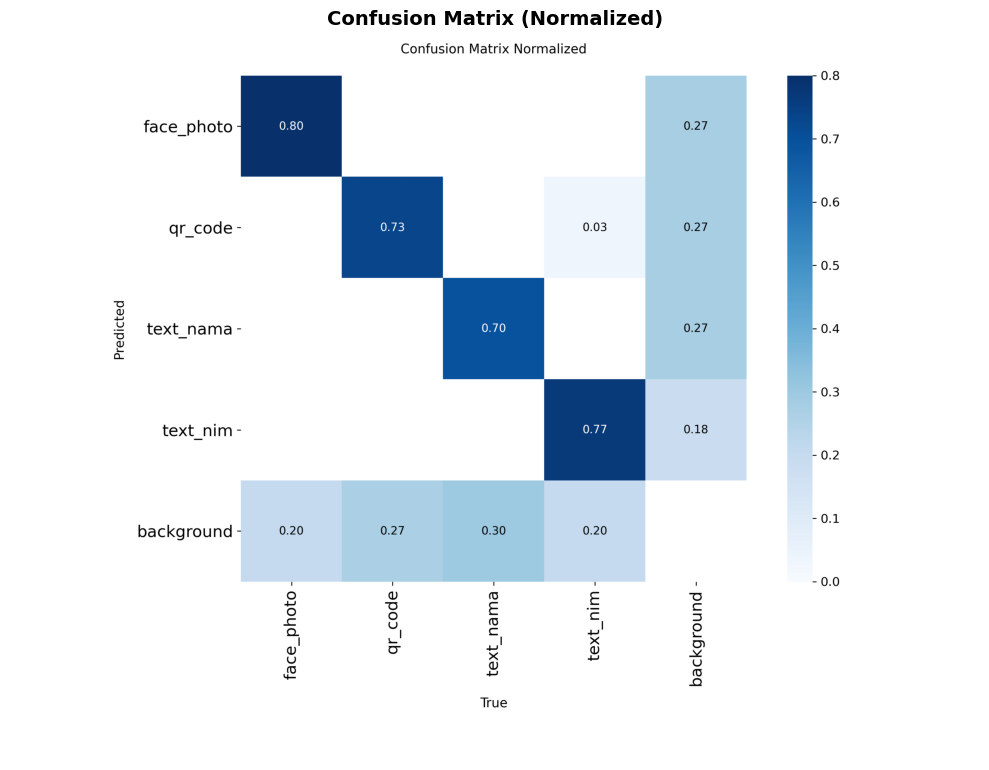

✅ Confusion Matrix — simpan untuk laporan!


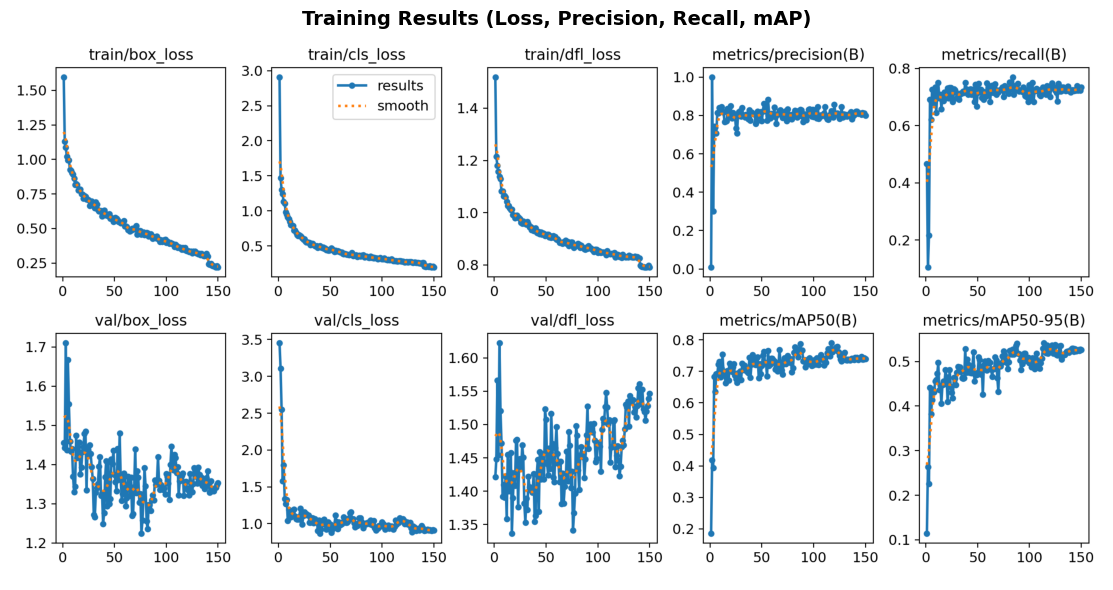

⚠️ F1_curve.png tidak ditemukan
⚠️ PR_curve.png tidak ditemukan
⚠️ P_curve.png tidak ditemukan
⚠️ R_curve.png tidak ditemukan


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

\n✅ Semua plot evaluasi di-download sebagai evaluation_plots.zip


In [7]:
# --- Jalankan di Colab Cell 5B ---
# Generate confusion matrix dan visualisasi training curves

import matplotlib.pyplot as plt
from matplotlib.image import imread
import os
import glob

train_dir = "runs/detect/smartlab-ktm"

# ── Confusion Matrix ──
cm_path = os.path.join(train_dir, "confusion_matrix_normalized.png")
if os.path.exists(cm_path):
    plt.figure(figsize=(10, 8))
    plt.imshow(imread(cm_path))
    plt.axis("off")
    plt.title("Confusion Matrix (Normalized)", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print("✅ Confusion Matrix — simpan untuk laporan!")
else:
    print("⚠️ Confusion matrix tidak ditemukan di:", cm_path)

# ── Training Curves ──
curves = [
    ("results.png", "Training Results (Loss, Precision, Recall, mAP)"),
    ("F1_curve.png", "F1-Confidence Curve"),
    ("PR_curve.png", "Precision-Recall Curve"),
    ("P_curve.png", "Precision-Confidence Curve"),
    ("R_curve.png", "Recall-Confidence Curve"),
]

for fname, title in curves:
    fpath = os.path.join(train_dir, fname)
    if os.path.exists(fpath):
        plt.figure(figsize=(12, 6))
        plt.imshow(imread(fpath))
        plt.axis("off")
        plt.title(title, fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
    else:
        print(f"⚠️ {fname} tidak ditemukan")

# ── Download semua plot sebagai ZIP ──
import shutil
plots_dir = "/content/evaluation_plots"
os.makedirs(plots_dir, exist_ok=True)

for fname, _ in curves:
    src = os.path.join(train_dir, fname)
    if os.path.exists(src):
        shutil.copy(src, plots_dir)

# Copy confusion matrices
for cm in ["confusion_matrix.png", "confusion_matrix_normalized.png"]:
    src = os.path.join(train_dir, cm)
    if os.path.exists(src):
        shutil.copy(src, plots_dir)

# Zip and download
shutil.make_archive("/content/evaluation_plots", "zip", plots_dir)
from google.colab import files
files.download("/content/evaluation_plots.zip")
print("\\n✅ Semua plot evaluasi di-download sebagai evaluation_plots.zip")

In [8]:
# --- Jalankan di Colab Cell 5C ---
# Generate tabel ringkasan yang siap copy-paste ke laporan

from ultralytics import YOLO

model = YOLO("runs/detect/smartlab-ktm/weights/best.pt")
metrics = model.val(split="test")

class_names = list(model.names.values())
p = metrics.box.mp
r = metrics.box.mr
f1 = 2 * (p * r) / (p + r) if (p + r) > 0 else 0

print("\\n" + "=" * 70)
print("TABEL UNTUK LAPORAN (format Markdown — bisa paste ke Word/Docs)")
print("=" * 70)

# Tabel 1: Overall
print("\\n### Tabel 1: Hasil Evaluasi Model YOLOv8 (Overall)")
print("| Metrik | Nilai |")
print("|--------|-------|")
print(f"| Precision | {p:.4f} ({p:.1%}) |")
print(f"| Recall | {r:.4f} ({r:.1%}) |")
print(f"| F1 Score | {f1:.4f} ({f1:.1%}) |")
print(f"| mAP@50 | {metrics.box.map50:.4f} ({metrics.box.map50:.1%}) |")
print(f"| mAP@50-95 | {metrics.box.map:.4f} ({metrics.box.map:.1%}) |")
total_speed = sum(metrics.speed.values())
print(f"| Inference Speed | {metrics.speed['inference']:.1f}ms/image |")

# Tabel 2: Per-Class
print("\\n### Tabel 2: Evaluasi Per-Kelas Objek")
print("| Kelas | Precision | Recall | F1 | AP@50 |")
print("|-------|-----------|--------|----|-------|")
for i, name in enumerate(class_names):
    pc = metrics.box.p[i] if i < len(metrics.box.p) else 0
    rc = metrics.box.r[i] if i < len(metrics.box.r) else 0
    f1c = 2 * (pc * rc) / (pc + rc) if (pc + rc) > 0 else 0
    ap50 = metrics.box.ap50[i] if i < len(metrics.box.ap50) else 0
    print(f"| {name} | {pc:.4f} | {rc:.4f} | {f1c:.4f} | {ap50:.4f} |")


Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1942.9±548.8 MB/s, size: 149.2 KB)
val: Scanning /content/ktm-7/test/labels... 124 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 124/124 1.6Kit/s 0.1s
val: New cache created: /content/ktm-7/test/labels.cache
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 4, len(boxes) = 496. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 2.4it/s 3.3s
                   all        124        496      0.803      0.848      0.809      0.443
            face_photo        124        124      0.961      0.998      0.995      0.707


Saving IMG-20260311-WA0049.jpg to IMG-20260311-WA0049.jpg

image 1/1 /content/IMG-20260311-WA0049.jpg: 640x416 2 face_photos, 1 qr_code, 1 text_nama, 1 text_nim, 62.4ms
Speed: 4.5ms preprocess, 62.4ms inference, 2.1ms postprocess per image at shape (1, 3, 640, 416)


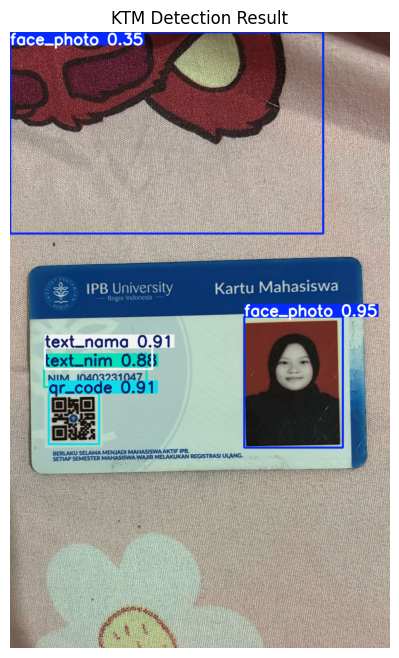

  Detected: face_photo (95.2%)
  Detected: text_nama (91.0%)
  Detected: qr_code (90.8%)
  Detected: text_nim (88.1%)
  Detected: face_photo (35.3%)


In [9]:
# --- Jalankan di Colab Cell 6 ---
from ultralytics import YOLO
from google.colab import files
import cv2
from matplotlib import pyplot as plt
model = YOLO("runs/detect/smartlab-ktm/weights/best.pt")
# Upload gambar test
uploaded = files.upload()
filename = list(uploaded.keys())[0]
# Prediksi
results = model.predict(filename, conf=0.35)
# Tampilkan
result_img = results[0].plot()
plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("KTM Detection Result")
plt.show()
# Print detections
for box in results[0].boxes:
    cls_name = model.names[int(box.cls[0])]
    conf = float(box.conf[0])
    print(f"  Detected: {cls_name} ({conf:.1%})")

In [12]:
# --- Jalankan di Colab Cell 7 ---
from google.colab import files
# Download best.pt ke laptop Anda
files.download("runs/detect/smartlab-ktm/weights/best.pt")
print("\\n✅ SELESAI! Copy file best.pt yang ter-download ke folder:")
print("   ScanKtm/models/best.pt")
print("\\nLalu jalankan: python test_webcam.py")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

\n✅ SELESAI! Copy file best.pt yang ter-download ke folder:
   ScanKtm/models/best.pt
\nLalu jalankan: python test_webcam.py
